<a href="https://colab.research.google.com/github/goetzdominik/Digichem/blob/main/digichem_combined_24_05_2025.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [44]:
# Now, import the libraries
import pandas as pd
from collections import Counter
import numpy as np
from ase import Atoms
from dscribe.descriptors import SOAP
import pymatgen
from pymatgen.core import Element
from mendeleev import element
import ast
from rdkit.Chem import GetPeriodicTable
from pymatgen.core import Composition

In [45]:
pd.set_option('display.max_rows', 10)  # Display 10 rows
pd.set_option('display.max_columns', 100)  # Display 100 columns


In [46]:
#read in the csv files (that were extracted directly from the materials database)
df_ABC3 = pd.read_csv("ABC3_filtered.csv", usecols= ['formula_pretty','elements', 'band_gap','energy_above_hull','formation_energy_per_atom','density',"structure.sites"])

df_A2BCX6 = pd.read_csv("A2BCX6_filtered.csv", usecols= ['formula_pretty','elements', 'band_gap','energy_above_hull','formation_energy_per_atom','density',"structure.sites"])

# Use .apply(ast.literal_eval) directly on the 'elements' column Series.
# This applies the function element-wise to each string in the Series.
df_A2BCX6['elements'] = df_A2BCX6['elements'].apply(ast.literal_eval)
df_ABC3['elements'] = df_ABC3['elements'].apply(ast.literal_eval)

In [47]:

#make a total df and a leadfree df -maybe more-
df_total = pd.concat([df_ABC3, df_A2BCX6], axis=0,ignore_index=True)

df_leadfree = df_total[df_total['formula_pretty'].str.contains('Pb')==False]

In [48]:
#Filtering for the elemental abundance based on df_total
df_temp= df_total

# Define your abundance threshold
abundance_threshold = 10  # Example threshold in ppm

#Defining elemental abundance dictionary (abundance in ppm from "Abundance of Elements in the Earth's Crust and in the Sea", CRC Handbook of Chemistry and Physics, 97th edition (2016–2017), sec. 14, pg. 17)
elemental_abundance = {
    'Ac' : 0.000000000055,
    'Ag' : 0.075,
    'Al' : 82300,
    'Ar' : 3.5,
    'As' : 1.8,
    'At' : 0.000000000005,
    'Au' : 0.004,
    'B' : 10,
    'Ba' : 425,
    'Be' : 2.8,
    'Bi' : 0.0085,
    'Br' : 2.4,
    'C' : 200,
    'Ca' : 41500,
    'Cd' : 0.15,
    'Ce' : 66.5,
    'Cl' : 145,
    'Co' : 25,
    'Cr' : 102,
    'Cs' : 3,
    'Cu' : 60,
    'Dy' : 5.2,
    'Er' : 3.5,
    'Eu' : 2,
    'F' : 585,
    'Fe' : 56300,
    'Fr' : 0.000000000005,
    'Ga' : 19,
    'Gd' : 6.2,
    'Ge' : 1.5,
    'H' : 1400,
    'He' : 0.008,
    'Hf' : 3.0,
    'Hg' : 0.085,
    'Ho' : 1.3,
    'I' : 0.45,
    'In' : 0.25,
    'Ir' : 0.001,
    'K' : 20900,
    'Kr' : 0.0001,
    'La' : 39,
    'Li' : 20,
    'Lu' : 0.8,
    'Mg' : 23300,
    'Mn' : 950,
    'Mo' : 1.2,
    'N' : 19,
    'Na' : 23600,
    'Nb' : 20,
    'Nd' : 41.5,
    'Ne' : 0.005,
    'Ni' : 84,
    'Np' : 0.00000000005,
    'O' : 461000,
    'Os' : 0.0015,
    'P' : 1050,
    'Pa' : 0.00000000005,
    'Pb' : 14,
    'Pd' : 0.015,
    'Pm' : 0.00000000005,
    'Po' : 0.00000000002,
    'Pr' : 9.2,
    'Pt' : 0.005,
    'Pu' : 0.00000000005,
    'Ra' : 0.0000009,
    'Rb' : 90,
    'Re' : 0.0007,
    'Rh' : 0.001,
    'Rn' : 0.0000000000004,
    'Ru' : 0.001,
    'S' : 350,
    'Sb' : 0.2,
    'Sc' : 22,
    'Se' : 0.05,
    'Si' : 282000,
    'Sm' : 7.05,
    'Sn' : 2.3,
    'Sr' : 370,
    'Ta' : 2.0,
    'Tb' : 1.2,
    'Tc' : 0.0000000005,
    'Te' : 0.001,
    'Th' : 9.6,
    'Ti' : 5650,
    'Tl' : 0.85,
    'Tm' : 0.52,
    'U' : 2.7,
    'V' : 120,
    'W' : 1.25,
    'Xe' : 0.00003,
    'Y' : 33,
    'Yb' : 3.2,
    'Zn' : 70,
    'Zr' : 165
}


def is_abundant_perovskite(elements, abundance_data, threshold):
    """
    Checks if all elements in a list are above the abundance threshold.

    Args:
        elements (list): A list of element symbols from the perovskite composition (e.g., ['Ni', 'O', 'Sr', 'W']).
        abundance_data (dict): A dictionary of elemental abundances (e.g., {'Ni': 84, ...}).
        threshold (float): The minimum abundance threshold.

    Returns:
        bool: True if all elements are above the threshold, False otherwise.
    """
    for element in elements:
        if element in abundance_data and abundance_data[element] <= threshold:
            return False
        elif element not in abundance_data:
            print(f"Warning: Abundance data not found for element '{element}'. Assuming it's not abundant.")
            return False  # Or you could choose to handle missing data differently
    return True

if 'elements' in df_temp.columns:
   # df_temp['elements'] = df_temp['elements'].apply(ast.literal_eval)

    # Apply the function to each row of the DataFrame
    abundant_mask = df_temp['elements'].apply(lambda x: is_abundant_perovskite(x, elemental_abundance, abundance_threshold))

    # Filter the DataFrame using the boolean mask
    df_abundant_perovskites = df_temp[abundant_mask]

    print(f"Original DataFrame shape: {df_temp.shape}")
    print(f"Filtered DataFrame shape (threshold = {abundance_threshold} ppm): {df_abundant_perovskites.shape}")
    # Now 'abundant_perovskites_df' contains only the structures where all elements
    # have a natural abundance greater than or equal to the threshold.
    # print(abundant_perovskites_df.head())
else:
    print("Error: The 'elements' column was not found in the DataFrame.")

#define dataframe based on the above functions
df_abundant = df_abundant_perovskites

Original DataFrame shape: (1424, 7)
Filtered DataFrame shape (threshold = 10 ppm): (385, 7)


In [49]:
# #put dfs into list to apply all following operations to all of them
# df_names = ["df_ABC3", "df_A2BCX6", "df_total", "df_leadfree", "df_abundandt"]
# list_of_dfs = [df_ABC3, df_A2BCX6, df_total, df_leadfree, df_abundant]

#put dfs into list to apply all following operations to all of them
df_names = ["df_total", "df_leadfree", "df_abundant"]
list_of_dfs = [df_total, df_leadfree, df_abundant]

In [50]:
#functions for property dictionary (i.e. handly missing values etc.)
missing_fusion_heats = {
    "As": 24.44,  # kJ/mol
    "O" : 0.44,
    "N" : 0.72,
    "C" : 117,
    "Ru" : 38.59,
    "Tb" : 10.15,
    "Gd" : 10.05,
    "Dy" : 11.06,
    "Eu" : 9.21,
    "Ho" : 17.0,
    "Er" : 19.9,
    "Lu" : 22,
    "Tm" : 16.84
}



def get_fusion_heat(element_symbol):
    elmt = element(element_symbol)
    if elmt.fusion_heat is None and element_symbol in missing_fusion_heats:
        return missing_fusion_heats[element_symbol]
    elif elmt.fusion_heat is None and element_symbol not in missing_fusion_heats:
        print(elmt.name, "is missing fusion heat value")
    else:
        return elmt.fusion_heat

missing_evaporation_heats = {
    "O" : 6.82, # kJ/mol
    "N" : 5.58,
    "C" : 715,
    "Ru" : 619,
    "Tb" : 391
}



def get_evaporation_heat(element_symbol):
    elmt = element(element_symbol)
    if elmt.evaporation_heat is None and element_symbol in missing_evaporation_heats:
        return missing_evaporation_heats[element_symbol]
    else:
        return elmt.evaporation_heat

missing_specific_heats = {
    "Pa" : 99.1,
    "Tc" : 63
}

def get_specific_heat(element_symbol):
    elmt = element(element_symbol)
    if elmt.specific_heat is None and element_symbol in missing_specific_heats:
        return missing_specific_heats[element_symbol]
    else:
        return elmt.specific_heat

def get_boiling_point(element_symbol):
    elmt = element(element_symbol)
    if element_symbol == "Pa":
        return 4000
    elif element_symbol == "P":
        return 550
    else:
        return elmt.boiling_point


#define function to handle missing values (use atomic radius instead of calculated and use atomic mass/molar volume instead of density of solid)
def get_atomic_radius_calculated(elmt_pymatgen_temp):
    atomic_radius_calculated_temp = elmt_pymatgen_temp.atomic_radius_calculated
    if atomic_radius_calculated_temp == None:
        return elmt_pymatgen_temp.atomic_radius
    else :
      return atomic_radius_calculated_temp

def get_density_of_solid(elmt_pymatgen_temp):
    density_of_solid_temp = elmt_pymatgen_temp.density_of_solid
    if density_of_solid_temp == None:
        return elmt_pymatgen_temp.atomic_mass / elmt_pymatgen_temp.molar_volume
    else :
      return density_of_solid_temp/1000

#define function to get number of valence electrons
pt = GetPeriodicTable()

def get_valence(element_symbol):
  valence = pt.GetNOuterElecs(element_symbol)
  return valence

In [51]:
#create dictionary with the values for all elements (so that the loop over all formulas is faster) (takes approx 4 minutes now)

#find all elements in the csv file to create input for dictionary creation
#use df_total to find all the elements that could be in the other dfs
elements_list = df_total["elements"]
elements_vector = []
# Iterate directly over the values of the Series
for formula_str in elements_list:
  # Safely evaluate each string as a list #I have no idea why this is not needed anymore ?
  # formula = ast.literal_eval(formula_str)
  formula = formula_str
  # Iterate over the elements in the list
  for elmt in formula:
    elements_vector.append(elmt)

elements_vector = pd.Series(elements_vector).drop_duplicates().tolist() # Deduplicate elements


#loop over the found unique elements and define the needed properties
elemental_properties = {}  #dictionary to be filled

for symbol in elements_vector:
    #define strings as "elements"
    elmt_pymatgen = Element(symbol)
    elmt_mendeleev = element(symbol)

    properties = {
        'atomic_mass': elmt_pymatgen.atomic_mass,
        'Z': elmt_pymatgen.Z,
        'group': elmt_pymatgen.group,
        'fusion_heat': get_fusion_heat(symbol),  # Use custom function
        'evaporation_heat': get_evaporation_heat(symbol),  # Use custom function
        'specific_heat': get_specific_heat(symbol), # Use custom function
        'row': elmt_pymatgen.row,
        'mendeleev_no': elmt_pymatgen.mendeleev_no,
        'iupac_ordering': elmt_pymatgen.iupac_ordering,
        'average_ionic_radius': elmt_pymatgen.average_ionic_radius,
        'atomic_radius': elmt_pymatgen.atomic_radius,
        'atomic_radius_calculated': get_atomic_radius_calculated(elmt_pymatgen), # Use custom function
        'van_der_waals_radius': elmt_pymatgen.van_der_waals_radius,
        'X': elmt_pymatgen.X,
        'electron_affinity': elmt_pymatgen.electron_affinity,
        'ionization_energy': elmt_pymatgen.ionization_energy,
        'valence': get_valence(symbol), # Use custom function
        'density_of_solid': get_density_of_solid(elmt_pymatgen), # Use custom function
        'molar_volume': elmt_pymatgen.molar_volume,
        'boiling_point': get_boiling_point(symbol), # Use custom function
        'melting_point': elmt_pymatgen.melting_point,
        'thermal_conductivity': elmt_pymatgen.thermal_conductivity

    }

    elemental_properties[symbol] = properties  # For dictionary


C:\Users\moorh\AppData\Local\Temp\ipykernel_81492\3501271099.py:77: UserWarning: No data available for density_of_solid for Br
  density_of_solid_temp = elmt_pymatgen_temp.density_of_solid
C:\Users\moorh\AppData\Local\Temp\ipykernel_81492\3501271099.py:77: UserWarning: No data available for density_of_solid for O
  density_of_solid_temp = elmt_pymatgen_temp.density_of_solid
C:\Users\moorh\AppData\Local\Temp\ipykernel_81492\3501271099.py:77: UserWarning: No data available for density_of_solid for Cl
  density_of_solid_temp = elmt_pymatgen_temp.density_of_solid
C:\Users\moorh\AppData\Local\Temp\ipykernel_81492\3501271099.py:77: UserWarning: No data available for density_of_solid for N
  density_of_solid_temp = elmt_pymatgen_temp.density_of_solid
C:\Users\moorh\AppData\Local\Temp\ipykernel_81492\3501271099.py:77: UserWarning: No data available for density_of_solid for F
  density_of_solid_temp = elmt_pymatgen_temp.density_of_solid
C:\Users\moorh\AppData\Local\Temp\ipykernel_81492\35012710

In [52]:
#define function to get from raw dataframes to dataframes with elemental properties, based on "formula pretty" and "elements"
def get_df_with_properties(df):
  df = df
  #loop over all entries and extract the corresponding elements
  for index, formula in df["elements"].items():
    comp = Composition(df["formula_pretty"][index])
    #reformat to list (why not needed anymore??)
    #elements = ast.literal_eval(formula)
    elements = formula

    #calculate property and mean/sd
    #define empty vectors
    atomic_mass = []
    Z = []
    group = []
    row = []
    mendeleev_no = []
    iupac_ordering = []
    average_ionic_radius = []
    atomic_radius = []
    atomic_radius_calculated = []
    van_der_waals_radius = []
    X = []
    electron_affinity = []
    ionization_energy = []
    valence = []
    density_of_solid = []
    molar_volume = []
    fusion_heat = []
    evaporation_heat = []
    specific_heat = []
    bp = []
    mp = []

  #use the library to assign the properties
    for elmt in elements:
      elmt_pymatgen = Element(elmt)
      element_amount = comp[elmt_pymatgen]
      counter = element_amount
      #loop over the number of times the specific element occurs in the formula so that mean and sd are correct
      while counter > 0:
        atomic_mass.append(elemental_properties[elmt]['atomic_mass'])
        Z.append(elemental_properties[elmt]['Z'])
        group.append(elemental_properties[elmt]['group'])
        row.append(elemental_properties[elmt]['row'])
        mendeleev_no.append(elemental_properties[elmt]['mendeleev_no'])
        iupac_ordering.append(elemental_properties[elmt]['iupac_ordering'])
        average_ionic_radius.append(elemental_properties[elmt]['average_ionic_radius'])
        atomic_radius.append(elemental_properties[elmt]['atomic_radius'])
        atomic_radius_calculated.append(elemental_properties[elmt]['atomic_radius_calculated'])
        van_der_waals_radius.append(elemental_properties[elmt]['van_der_waals_radius'])
        X.append(elemental_properties[elmt]['X'])
        electron_affinity.append(elemental_properties[elmt]['electron_affinity'])
        ionization_energy.append(elemental_properties[elmt]['ionization_energy'])
        valence.append(elemental_properties[elmt]['valence'])
        density_of_solid.append(elemental_properties[elmt]['density_of_solid'])
        molar_volume.append(elemental_properties[elmt]['molar_volume'])
        fusion_heat.append(elemental_properties[elmt]['fusion_heat'])
        evaporation_heat.append(elemental_properties[elmt]['evaporation_heat'])
        specific_heat.append(elemental_properties[elmt]['specific_heat'])
        bp.append(elemental_properties[elmt]['boiling_point'])
        mp.append(elemental_properties[elmt]['melting_point'])
        counter -= 1

    mean_atomic_mass = np.mean(atomic_mass)
    std_atomic_mass = np.std(atomic_mass)
    mean_Z = np.mean(Z)
    std_Z = np.std(Z)
    mean_group = np.mean(group)
    std_group = np.std(group)
    mean_row = np.mean(row)
    std_row = np.std(row)
    mean_mendeleev_no = np.mean(mendeleev_no)
    std_mendeleev_no = np.std(mendeleev_no)
    mean_iupac_ordering = np.mean(iupac_ordering)
    std_iupac_ordering = np.std(iupac_ordering)
    mean_average_ionic_radius = np.mean(average_ionic_radius)
    std_average_ionic_radius = np.std(average_ionic_radius)
    mean_atomic_radius = np.mean(atomic_radius)
    std_atomic_radius = np.std(atomic_radius)
    mean_atomic_radius_calculated = np.mean(atomic_radius_calculated)
    std_atomic_radius_calculated = np.std(atomic_radius_calculated)
    mean_van_der_waals_radius = np.mean(van_der_waals_radius)
    std_van_der_waals_radius = np.std(van_der_waals_radius)
    mean_X = np.mean(X)
    std_X = np.std(X)
    mean_electron_affinity = np.mean(electron_affinity)
    std_electron_affinity = np.std(electron_affinity)
    mean_ionization_energy = np.mean(ionization_energy)
    std_ionization_energy = np.std(ionization_energy)
    mean_valence = np.mean(valence)
    std_valence = np.std(valence)
    mean_density_of_solid = np.mean(density_of_solid)
    std_density_of_solid = np.std(density_of_solid)
    mean_molar_volume = np.mean(molar_volume)
    std_molar_volume = np.std(molar_volume)
    mean_fusion_heat = np.mean(fusion_heat)
    std_fusion_heat = np.std(fusion_heat)
    mean_evaporation_heat = np.mean(evaporation_heat)
    std_evaporation_heat = np.std(evaporation_heat)
    mean_specific_heat = np.mean(specific_heat)
    std_specific_heat = np.std(specific_heat)
    mean_bp = np.mean(bp)
    std_bp = np.std(bp)
    mean_mp = np.mean(mp)
    std_mp = np.std(mp)

    #add to dataframe
    df.at[index, 'atom_mass_mean'] = mean_atomic_mass
    df.at[index, 'atom_mass_std'] = std_atomic_mass
    df.at[index, 'Z_mean'] = mean_Z
    df.at[index, 'Z_std'] = std_Z
    df.at[index, 'group_mean'] = mean_group
    df.at[index, 'group_std'] = std_group
    df.at[index, 'row_mean'] = mean_row
    df.at[index, 'row_std'] = std_row
    df.at[index, 'mendeleev_no_mean'] = mean_mendeleev_no
    df.at[index, 'mendeleev_no_std'] = std_mendeleev_no
    df.at[index, 'iupac_ordering_mean'] = mean_iupac_ordering
    df.at[index, 'iupac_ordering_std'] = std_iupac_ordering
    df.at[index, 'average_ionic_radius_mean'] = mean_average_ionic_radius
    df.at[index, 'average_ionic_radius_std'] = std_average_ionic_radius
    df.at[index, 'atomic_radius_mean'] = mean_atomic_radius
    df.at[index, 'atomic_radius_std'] = std_atomic_radius
    df.at[index, 'atomic_radius_calculated_mean'] = mean_atomic_radius_calculated
    df.at[index, 'atomic_radius_calculated_std'] = std_atomic_radius_calculated
    df.at[index, 'van_der_waals_radius_mean'] = mean_van_der_waals_radius
    df.at[index, 'van_der_waals_radius_std'] = std_van_der_waals_radius
    df.at[index, 'X_mean'] = mean_X
    df.at[index, 'X_std'] = std_X
    df.at[index, 'electron_affinity_mean'] = mean_electron_affinity
    df.at[index, 'electron_affinity_std'] = std_electron_affinity
    df.at[index, 'ionization_energy_mean'] = mean_ionization_energy
    df.at[index, 'ionization_energy_std'] = std_ionization_energy
    df.at[index, 'valence_mean'] = mean_valence
    df.at[index, 'valence_std'] = std_valence
    df.at[index, 'density_of_solid_mean'] = mean_density_of_solid
    df.at[index, 'density_of_solid_std'] = std_density_of_solid
    df.at[index, 'molar_volume_mean'] = mean_molar_volume
    df.at[index, 'molar_volume_std'] = std_molar_volume
    df.at[index, 'fusion_heat_mean'] = mean_fusion_heat
    df.at[index, 'fusion_heat_std'] = std_fusion_heat
    df.at[index, 'evaporation_heat_mean'] = mean_evaporation_heat
    df.at[index, 'evaporation_heat_std'] = std_evaporation_heat
    df.at[index, 'specific_heat_mean'] = mean_specific_heat
    df.at[index, 'specific_heat_std'] = std_specific_heat
    df.at[index, 'bp_mean'] = mean_bp
    df.at[index, 'bp_std'] = std_bp
    df.at[index, 'mp_mean'] = mean_mp
    df.at[index, 'mp_std'] = std_mp
    index += 1
  return df

In [53]:
##Code für SOAP descriptors (mehr oder weniger direkt von Dominik/Fabian kopiert)

def get_data (df):
    # expects a dataframe with the following columns: "elements", "structure.sites"

    # returns a dataframe where the elements and structure.sites string are split and unnecessary character removed

    df_curated = pd.DataFrame()

    # df["elements"] = df["elements"].apply(lambda x: x if isinstance(x, str) else "")
    # this line above seems to be important so that we can split the string, but this creates a problem later on, where we get an elemntal entry that is '' so nothing
    # df = df[df["elements"].apply(lambda x: isinstance(x, str))]



    df_curated["Elements"] = df["elements"]

    # df_curated["band_gap"] = df["band_gap"]
    # df_curated["formula_pretty"] = df["formula_pretty"]
    # df["structure.sites"] = df["structure.sites"].apply(lambda x: x if isinstance(x, str) else "")
    df_curated["structure_string"] = df["structure.sites"]
    df_curated["structure_string_split"] = None



    for i in range(df_curated.shape[0]):


        df_curated["structure_string_split"].iloc[i] = df_curated["structure_string"].iloc[i].split()

        # #cleans the structure string and removes all the unnecessary characters
        for j in range(len(df_curated["structure_string_split"].iloc[i])):


            df_curated["structure_string_split"].iloc[i][j] = df_curated["structure_string_split"].iloc[i][j].replace("{","")
            df_curated["structure_string_split"].iloc[i][j] = df_curated["structure_string_split"].iloc[i][j].replace("}","")
            df_curated["structure_string_split"].iloc[i][j] = df_curated["structure_string_split"].iloc[i][j].replace("[","")
            df_curated["structure_string_split"].iloc[i][j] = df_curated["structure_string_split"].iloc[i][j].replace("]","")
            df_curated["structure_string_split"].iloc[i][j] = df_curated["structure_string_split"].iloc[i][j].replace(":","")
            df_curated["structure_string_split"].iloc[i][j] = df_curated["structure_string_split"].iloc[i][j].replace("'","")
            df_curated["structure_string_split"].iloc[i][j] = df_curated["structure_string_split"].iloc[i][j].replace(",","")

        #df_curated["Elements"].iloc[i] = df_curated["Elements"].iloc[i].split(",")
        for k in range(len(df_curated["Elements"].iloc[i])):
            df_curated["Elements"].iloc[i][k] = df_curated["Elements"].iloc[i][k].replace("'", "")
            df_curated["Elements"].iloc[i][k] = df_curated["Elements"].iloc[i][k].replace("[", "")
            df_curated["Elements"].iloc[i][k] = df_curated["Elements"].iloc[i][k].replace("]", "")
            df_curated["Elements"].iloc[i][k] = df_curated["Elements"].iloc[i][k].replace(" ", "")

    print("get data done")
    return df_curated




def split_df (df):
    # expects a dataframe with the following columns: "structure_string_split" where each elements has 18 entires
    # select only the positons with relevant data and store them as a touple of (element, [x,y,z])
    # returns the data frame with the appended column "positions" with the positions of the atoms in the structure


    df["positions"] = None
    for i in range(len(df["structure_string_split"])):
        position_i = []
        for j in range (0, len(df["structure_string_split"].iloc[i]), 18):
            element = df["structure_string_split"].iloc[i][j+2] # remove trailing comma
            x = float(df["structure_string_split"].iloc[i][j+15])
            y = float(df["structure_string_split"].iloc[i][j+16])
            z = float(df["structure_string_split"].iloc[i][j+17])
            position_i.append((element, [x, y, z]))
        df["positions"].iloc[i] = position_i


    print("split df done")
    return df


def get_ratio(df):
    # Input: pd.datafram with a column "positions" containing lists of tuples (element, [x, y, z])
    #
    # Output: appends dataframe with a new column "ratio" containing a sorted dictionary of elements and their ratios
    #
    df["ratio"] = None

    #loops over all entries in positions
    for i, atom_list in enumerate(df["positions"]):
        elements = [atom[0] for atom in atom_list]
        occurance = Counter(elements)

        counts = np.fromiter(occurance.values(), dtype=int)

        gcd = np.gcd.reduce(counts)


        reduced_occurance = {element: count // gcd for element, count in occurance.items()}

        # Sort by value so largest is last
        sorted_occurrence = dict(sorted(reduced_occurance.items(), key=lambda item: item[1]))

        df["ratio"].iloc[i] = sorted_occurrence

    return df


def get_ase(df):
    # expect a data frame with a column "positions" containing lists of tuples (element, [x, y, z])
    # returns a data frame with a new column "ase" containing ase atoms objects




    df["ase"] = None  # Optional, for clarity
    for i, row in df.iterrows():
        symbols = [atom[0] for atom in row["positions"]]
        positions = [atom[1] for atom in row["positions"]]

        atoms_obj = Atoms(symbols=symbols, positions=positions)
        df.at[i, "ase"] = atoms_obj
    return df


def get_soap(df, r_cut=19.0, n_max=2, l_max=2, sigma=1):
    # Automatically extract all unique species from df["Elements"]


    unique_species = sorted(set(e for row in df["Elements"] for e in row))

    # Create SOAP descriptor generator
    soap_generator = SOAP(
        species=unique_species,
        r_cut=r_cut,
        n_max=n_max,
        l_max=l_max,
        sigma=sigma,
        periodic=False,
        sparse=False,
        rbf = "gto"
    )

    # Generate and store SOAP descriptors
    soap_list = []
    for atoms in df["ase"]:
        descriptor = soap_generator.create(atoms)
        #this seems to make every soap have the same length
        avg_descriptor = np.mean(descriptor, axis=0) #check if this is the correct way to do it with stehpan

        soap_list.append(avg_descriptor)

    df["soap"] = soap_list
    return df


def append_soap(df):
    #combines all the function from above
    # expects a dataframe with the following columns: "elements", "structure.sites"

    # retrun the datafram with the soap descriptor column appended at the end
    df_soap = df.copy()
    df_soap = get_data(df_soap)
    df_soap = split_df(df_soap)
    df_soap = get_ase(df_soap)
    df_soap = get_soap(df_soap)
    df["elements"] = df_soap["Elements"]
    df_soap.drop(columns=["Elements","structure_string", "structure_string_split","positions","ase"], inplace=True)
    df = pd.concat([df, df_soap], axis=1)
    df.drop(columns=["structure.sites"], inplace=True)
    soap_array = np.array(df['soap'].to_list())

    # spits the soap array into multiple columns
    soap_columns = [f"soap_{i}" for i in range(soap_array.shape[1])]

    soap_df = pd.DataFrame(soap_array, columns=soap_columns, index=df.index)

    df = df.drop(columns=['soap']).join(soap_df)
    print("append soap done")

    return df


In [54]:
#process the raw dataframes from the list above, takes approx 1.5 min per dataframe
dfs_with_properties = [] # Create an empty list to store the processed dataframes

for df in list_of_dfs:
  processed_df = get_df_with_properties(df) #adds elemental properties from library
  #processed_df = append_soap(processed_df)  #adds soap descriptors
  dfs_with_properties.append(processed_df)

# You can access each processed dataframe by its index, e.g., dfs_with_properties[0], dfs_with_properties[1], etc.

C:\Users\moorh\AppData\Local\Temp\ipykernel_81492\655836365.py:109: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.at[index, 'atom_mass_mean'] = mean_atomic_mass
C:\Users\moorh\AppData\Local\Temp\ipykernel_81492\655836365.py:110: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.at[index, 'atom_mass_std'] = std_atomic_mass
C:\Users\moorh\AppData\Local\Temp\ipykernel_81492\655836365.py:111: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer

In [55]:
dfs_with_properties[0]

,elements,formula_pretty,density,formation_energy_per_atom,energy_above_hull,band_gap,structure.sites,atom_mass_mean,atom_mass_std,Z_mean,Z_std,group_mean,group_std,row_mean,row_std,mendeleev_no_mean,mendeleev_no_std,iupac_ordering_mean,iupac_ordering_std,average_ionic_radius_mean,average_ionic_radius_std,atomic_radius_mean,atomic_radius_std,atomic_radius_calculated_mean,atomic_radius_calculated_std,van_der_waals_radius_mean,van_der_waals_radius_std,X_mean,X_std,electron_affinity_mean,electron_affinity_std,ionization_energy_mean,ionization_energy_std,valence_mean,valence_std,density_of_solid_mean,density_of_solid_std,molar_volume_mean,molar_volume_std,fusion_heat_mean,fusion_heat_std,evaporation_heat_mean,evaporation_heat_std,specific_heat_mean,specific_heat_std,bp_mean,bp_std,mp_mean,mp_std
0,"[Ag, Br, S]",Ag3SBr,5.967646,-0.305716,0.098312,0.2964,"[{'species': [{'element': 'Ag', 'occu': 1}], '...",87.114720,29.579003,38.4,12.126005,13.2,2.712932,4.4,0.800000,81.0,12.312595,82.4,12.800000,1.004500,0.100636,1.390,0.261534,1.354,0.363021,1.996,0.140513,2.266,0.428700,1.870822,0.804134,8.980504,1.780257,9.2,2.227106,7.493927,3.727890,13.224,3.859459,9.530,4.184275,160.472,114.828707,0.3774,0.189452,1671.0320,943.768728,871.790,446.439341
1,"[Ag, I, S]",Ag3SI,6.576090,-0.260466,0.066818,0.5478,"[{'species': [{'element': 'Ag', 'occu': 1}], '...",96.514814,33.057549,42.0,13.206059,13.2,2.712932,4.6,0.800000,80.8,12.039934,82.2,12.528368,1.082667,0.124479,1.440,0.233238,1.396,0.322590,2.022,0.121885,2.206,0.338975,1.809914,0.692551,8.707994,1.386418,9.2,2.227106,7.674000,3.575308,14.412,6.009813,10.520,4.846417,162.950,112.077625,0.3254,0.191473,1696.1520,908.816808,896.000,415.103054
2,"[Ag, I, S]",Ag3SI,6.373934,-0.210889,0.116396,0.6243,"[{'species': [{'element': 'Ag', 'occu': 1}], '...",96.514814,33.057549,42.0,13.206059,13.2,2.712932,4.6,0.800000,80.8,12.039934,82.2,12.528368,1.082667,0.124479,1.440,0.233238,1.396,0.322590,2.022,0.121885,2.206,0.338975,1.809914,0.692551,8.707994,1.386418,9.2,2.227106,7.674000,3.575308,14.412,6.009813,10.520,4.846417,162.950,112.077625,0.3254,0.191473,1696.1520,908.816808,896.000,415.103054
3,"[Ag, As, O]",AgAsO3,5.320520,-1.243946,0.025765,0.5930,"[{'species': [{'element': 'Ag', 'occu': 1}], '...",46.157600,38.377381,20.8,16.289874,14.8,1.939072,3.0,1.264911,92.6,11.757551,90.4,9.707729,1.105333,0.232566,0.910,0.405463,0.846,0.476386,1.704,0.239883,2.886,0.683099,1.298460,0.254328,11.643790,2.517145,6.8,2.135416,3.796375,3.829478,15.060,2.941639,7.542,9.552885,61.392,96.861983,0.6636,0.312990,718.9728,912.177114,497.866,544.574780
4,"[Ag, Cl, O]",AgClO3,4.138469,-0.407245,0.038285,2.3983,"[{'species': [{'element': 'Ag', 'occu': 1}], '...",38.263880,35.608380,17.6,15.107614,15.2,2.135416,2.8,1.166190,94.6,11.825396,92.8,10.514752,1.129333,0.187123,0.880,0.391918,0.776,0.453193,1.684,0.230877,3.082,0.586119,1.860107,0.878406,12.279606,2.365140,7.2,1.939072,3.058715,3.740746,15.948,2.839024,3.936,4.626249,58.994,97.694887,0.6936,0.285459,588.9648,924.892757,314.186,462.589142
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1419,"[F, Mo, Na, Rb]",Rb2NaMoF6,3.901772,-2.980085,0.000000,4.1434,"[{'species': [{'element': 'Rb', 'occu': 1}], '...",40.385579,31.934603,18.1,13.538464,11.1,7.354590,3.0,1.341641,69.7,41.547683,69.5,41.950566,0.948500,0.379875,1.095,0.767936,1.162,0.939200,1.932,0.621511,2.861,1.416492,2.267414,1.390242,12.512268,6.061096,5.1,2.700000,2.448972,2.619144,21.188,17.706368,3.810,8.105857,87.874,170.942657,0.7149,0.282411,850.0780,1418.817998,421.297,834.380261
1420,"[F, Na, Rb, Rh]",Rb2NaRhF6,4.194014,-2.638313,0.000000,1.9570,"[{'species': [{'element': 'Rb', 'occu': 1}], '...",41.082129,33.190035,18.4,14.086873,11.4,7.200000,3.0,1.341641,70.6,41.338118,70.4,41.768888,0.945500,0.381349,1.085,0.763888,1.145,0.927149,1.925,0.619181,

In [56]:
#libraries to train the models on the created dataframes
import pylab as pl
import scipy.optimize as opt
from sklearn import preprocessing
from sklearn.model_selection import train_test_split
%matplotlib inline
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn import ensemble
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.inspection import permutation_importance

In [57]:
#define function to get X and y from a dataframe
def get_X_y(df):
  # Assign the 'band_gap' column to y and drop it from X
  y = df['band_gap']
  X = df.drop('band_gap', axis=1)

  #drop the irrelevant columns for the model (maybe move this to dataframe creation later)
  X = X.drop('formula_pretty', axis=1)
  X = X.drop('elements', axis=1)
  X = X.drop('structure.sites', axis=1)

  #temporarily also drop SOAPS for testing
  #X = X.drop('soap', axis=1)
  return X, y

--------------------------------------------
For dataframe: df_total
GBR Model| R2 sq on train set: 0.8399
GBR Model| R2 sq on test set: 0.7212
GBR Model| MSE on test set: 0.6632
GBR Model| MAE on test set: 0.6367


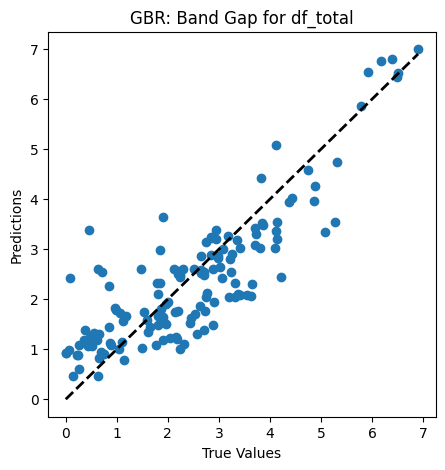

--------------------------------------------
--------------------------------------------
For dataframe: df_leadfree
GBR Model| R2 sq on train set: 0.8400
GBR Model| R2 sq on test set: 0.7449
GBR Model| MSE on test set: 0.7664
GBR Model| MAE on test set: 0.6594


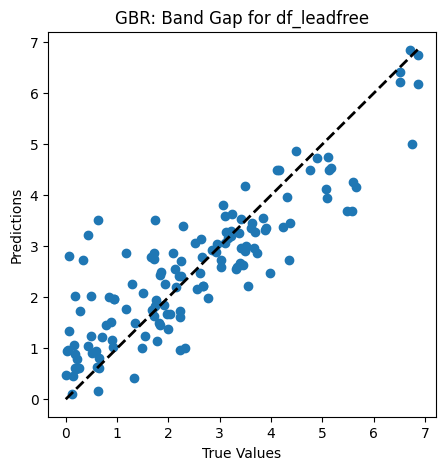

--------------------------------------------
--------------------------------------------
For dataframe: df_abundant
GBR Model| R2 sq on train set: 0.9434
GBR Model| R2 sq on test set: 0.7826
GBR Model| MSE on test set: 0.6931
GBR Model| MAE on test set: 0.6010


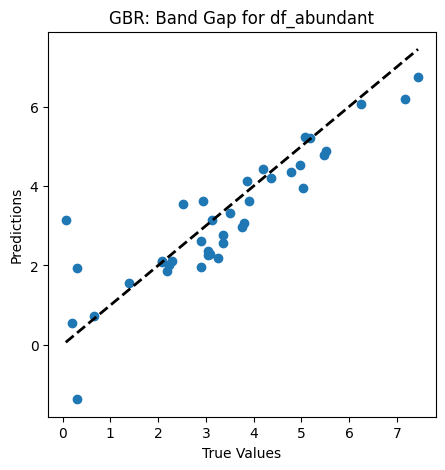

--------------------------------------------


In [58]:
#loop over all dataframes and train model GBR (takes approx 2 min per dataframe)
counter = 0
for df in dfs_with_properties:
  X, y = get_X_y(df)
  # Model 1 - Gradient boosting regression (GBR)
  from sklearn.ensemble import GradientBoostingRegressor
  X_train1, X_test1, y_train1, y_test1 = train_test_split( X, y, test_size=0.1, random_state=9)
  gbr = GridSearchCV (GradientBoostingRegressor (),{
      'n_estimators': [200], 'max_depth': [2], 'min_samples_split': [2], 'learning_rate': [0.1],
      'loss': ['squared_error'], 'random_state':[72]}, cv=5)
  gbr.fit(X_train1, y_train1)
  y_predicted1 = gbr.predict(X_test1)
  gbr_score = gbr.score(X_train1,y_train1)
  gbr_score1 = gbr.score(X_test1,y_test1)

  #calculate permutation based feature importance only for df_total
  if df_names[counter] == 'df_total':

    results = permutation_importance(gbr, X_test1, y_test1, n_repeats=5, random_state=42)
    importances = results.importances_mean
    feature_names = X_test1.columns

    importance_df_GBR = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importances
    })

    # Aggregate all SOAP feature importances into one
    soap_start_index = 49 # Index, ab dem die 'soap' Spalten beginnen (0-basiert)
    soap_columns = feature_names[soap_start_index:]

    # Sum of the SOAP importances
    soap_importance = importance_df_GBR[importance_df_GBR['Feature'].isin(soap_columns)]['Importance'].sum()

#print results + scatterplot
  print('--------------------------------------------')
  print('For dataframe:', df_names[counter])
  print('GBR Model| R2 sq on train set: %.4f'% gbr_score)
  print('GBR Model| R2 sq on test set: %.4f'% gbr_score1)
  print("GBR Model| MSE on test set: %.4f"% mean_squared_error(y_test1, y_predicted1))
  print("GBR Model| MAE on test set: %.4f"% mean_absolute_error(y_test1, y_predicted1))

  plt.figure(figsize=(5, 5))
  plt.plot([y_test1.min(), y_test1.max()], [y_test1.min(), y_test1.max()], 'k--', lw=2)
  plt.scatter(y_test1, y_predicted1)
  plt.xlabel("True Values")
  plt.ylabel("Predictions")
  plt.title("GBR: Band Gap for " + df_names[counter])
  plt.savefig(df_names[counter] + "_GBR_band_gap.png", dpi=300)
  plt.show()

  print('--------------------------------------------')
  counter += 1

#output jonas:  (sehr nahe an paper werten, minimal schlechter)
#GBR Model| R2 sq on train set: 0.9901
#GBR Model| R2 sq on test set: 0.7818
#GBR Model| MSE on test set: 0.5364
#GBR Model| MAE on test set: 0.5369

--------------------------------------------
For dataframe: df_total
SVR Model| R2 sq on train set: 0.9395
SVR Model| R2 sq on test set: 0.7548
SVR Model| MSE on test set: 0.6054
SVR Model| MAE on test set: 0.4908


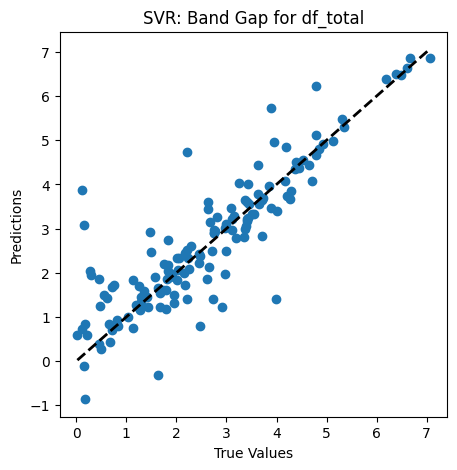

--------------------------------------------
--------------------------------------------
For dataframe: df_leadfree
SVR Model| R2 sq on train set: 0.9402
SVR Model| R2 sq on test set: 0.7917
SVR Model| MSE on test set: 0.5050
SVR Model| MAE on test set: 0.4688


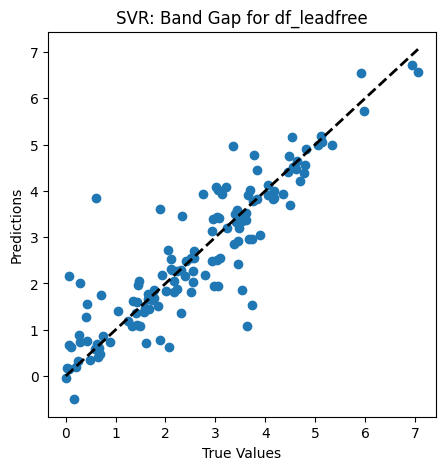

--------------------------------------------
--------------------------------------------
For dataframe: df_abundant
SVR Model| R2 sq on train set: 0.9428
SVR Model| R2 sq on test set: 0.7867
SVR Model| MSE on test set: 0.8124
SVR Model| MAE on test set: 0.6365


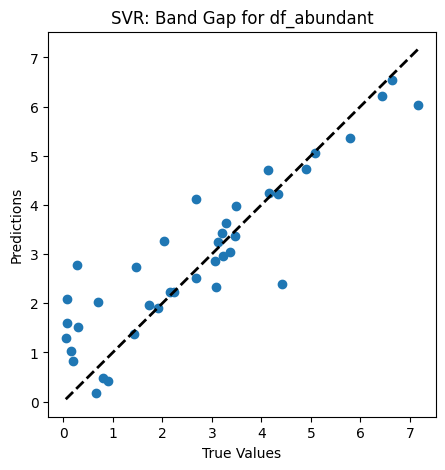

--------------------------------------------


In [59]:
#loop over all dataframes and train model SVR
from sklearn.svm import SVR
from sklearn.pipeline import Pipeline
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
counter = 0
for df in dfs_with_properties:
  X, y = get_X_y(df)

  X_train3, X_test3, y_train3, y_test3 = train_test_split( X, y, test_size=0.1, random_state=10)
  steps = [('scaler', StandardScaler()), ('SVM', SVR())]
  pipeline = Pipeline(steps)
  grid = GridSearchCV(pipeline, param_grid= {'SVM__C':[100], 'SVM__gamma':['auto'], 'SVM__kernel': ['rbf'],
                                            'SVM__epsilon':[0.001]}, cv=5)
  grid.fit(X_train3, y_train3)
  svr_score = grid.score(X_train3,y_train3)
  svr_score1 = grid.score(X_test3,y_test3)
  y_predicted3 = grid.predict(X_test3)

  # #calculate permutation based feature importance only for df_total
  # if df_names[counter] == 'df_total':
  #
  #   results = permutation_importance(grid, X_test3, y_test3, n_repeats=5, random_state=42)
  #   importances = results.importances_mean
  #   feature_names = X_test3.columns
  #
  #   importance_df_SVR = pd.DataFrame({
  #       'Feature': feature_names,
  #       'Importance': importances
  #   })
  #
  #   # Aggregate all SOAP feature importances into one
  #   soap_start_index = 49 # Index, ab dem die 'soap' Spalten beginnen (0-basiert)
  #   soap_columns = feature_names[soap_start_index:]
  #
  #   # Sum of the SOAP importances
  #   soap_importance = importance_df_SVR[importance_df_SVR['Feature'].isin(soap_columns)]['Importance'].sum()
#print results + scatterplot
  print('--------------------------------------------')
  print('For dataframe:', df_names[counter])
  print('SVR Model| R2 sq on train set: %.4f'% svr_score)
  print('SVR Model| R2 sq on test set: %.4f'% svr_score1)
  print('SVR Model| MSE on test set: %.4f'% mean_squared_error(y_test3, y_predicted3))
  print('SVR Model| MAE on test set: %.4f'% mean_absolute_error(y_test3, y_predicted3))
  plt.figure(figsize=(5, 5))
  plt.plot([y_test3.min(), y_test3.max()], [y_test3.min(), y_test3.max()], 'k--', lw=2)
  plt.scatter(y_test3, y_predicted3)
  plt.xlabel("True Values")
  plt.ylabel("Predictions")
  plt.title("SVR: Band Gap for " + df_names[counter])
  plt.savefig(df_names[counter] + "_SVR_band_gap.png", dpi=300)
  plt.show()

  print('--------------------------------------------')
  counter += 1
#output jonas ohne soaps (sehr nahe an paper werten):
#SVR Model| R2 sq on train set: 0.9361
#SVR Model| R2 sq on test set: 0.8253
#SVR Model| MSE on test set: 0.3971
#SVR Model| MAE on test set: 0.4428

--------------------------------------------
For dataframe: df_total
KNR Model| R2 sq on train set: 0.6654
KNR Model| R2 sq on test set: 0.4026
KNR Model| MSE on test set: 1.4211
KNR Model| MAE on test set: 0.8860


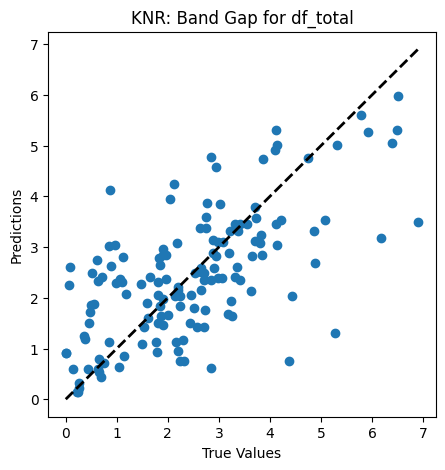

--------------------------------------------
--------------------------------------------
For dataframe: df_leadfree
KNR Model| R2 sq on train set: 0.6698
KNR Model| R2 sq on test set: 0.3840
KNR Model| MSE on test set: 1.8507
KNR Model| MAE on test set: 0.9915


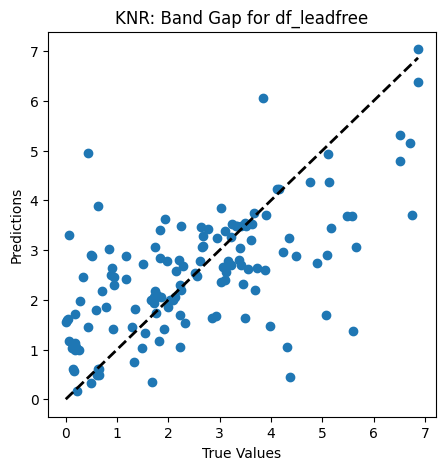

--------------------------------------------
--------------------------------------------
For dataframe: df_abundant
KNR Model| R2 sq on train set: 0.6439
KNR Model| R2 sq on test set: 0.3296
KNR Model| MSE on test set: 2.1371
KNR Model| MAE on test set: 1.0691


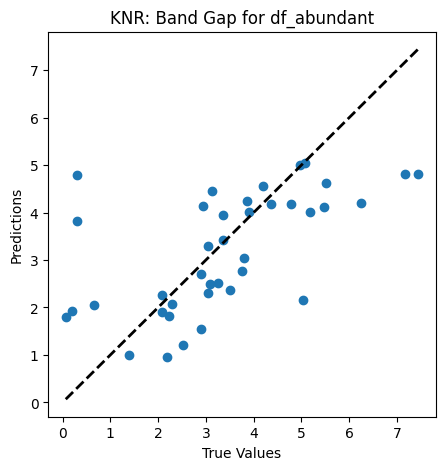

--------------------------------------------


In [60]:
#loop over all dataframes and train model KNR
from sklearn.neighbors import KNeighborsRegressor
counter = 0
for df in dfs_with_properties:
  X, y = get_X_y(df)

  X_train9, X_test9, y_train9, y_test9 = train_test_split( X, y, test_size=0.1, random_state=9)
  knr = GridSearchCV (KNeighborsRegressor(),{'n_neighbors':[4]}, cv=5)
  knr.fit(X_train9, y_train9)
  knr_score = knr.score(X_train9,y_train9)
  knr_score1 = knr.score(X_test9,y_test9)
  y_predicted9 = knr.predict(X_test9)


  # #calculate permutation based feature importance only for df_total
  # if df_names[counter] == 'df_total':
  #
  #   results = permutation_importance(knr, X_test9, y_test9, n_repeats=5, random_state=42)
  #   importances = results.importances_mean
  #   feature_names = X_test9.columns
  #
  #   importance_df_KNR = pd.DataFrame({
  #       'Feature': feature_names,
  #       'Importance': importances
  #   })
  #
  # # Aggregate all SOAP feature importances into one
  #   soap_start_index = 49 # Index, ab dem die 'soap' Spalten beginnen (0-basiert)
  #   soap_columns = feature_names[soap_start_index:]
  #
  # # Sum of the SOAP importances
  #   soap_importance = importance_df_KNR[importance_df_KNR['Feature'].isin(soap_columns)]['Importance'].sum()

#print results + scatterplot
  print('--------------------------------------------')
  print('For dataframe:', df_names[counter])
  print('KNR Model| R2 sq on train set: %.4f'% knr_score)
  print('KNR Model| R2 sq on test set: %.4f'% knr_score1)
  print('KNR Model| MSE on test set: %.4f'% mean_squared_error(y_test9, y_predicted9))
  print('KNR Model| MAE on test set: %.4f'% mean_absolute_error(y_test9, y_predicted9))

  plt.figure(figsize=(5, 5))
  plt.plot([y_test9.min(), y_test9.max()], [y_test9.min(), y_test9.max()], 'k--', lw=2)
  plt.scatter(y_test9, y_predicted9)
  plt.xlabel("True Values")
  plt.ylabel("Predictions")
  plt.title("KNR: Band Gap for " + df_names[counter])
  plt.savefig(df_names[counter] + "_KNR_band_gap.png", dpi=300)
  plt.show()

  print('--------------------------------------------')
  counter += 1

#ergebnisse jonas ohne soaps(sehr nahe an paper)
#KNR Model| R2 sq on train set: 0.6691
#KNR Model| R2 sq on test set: 0.4017
#KNR Model| MSE on test set: 1.4708
#KNR Model| MAE on test set: 0.9233

--------------------------------------------
For dataframe: df_total
RFR Model| R2 sq on train set: 0.9676
RFR Model| R2 sq on test set: 0.7795
RFR Model| MSE on test set: 0.5245
RFR Model| MAE on test set: 0.5279


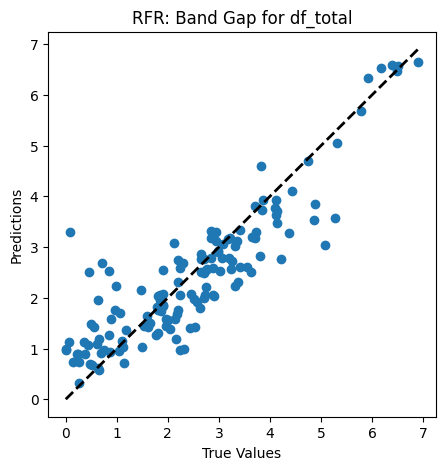

--------------------------------------------
--------------------------------------------
For dataframe: df_leadfree
RFR Model| R2 sq on train set: 0.9665
RFR Model| R2 sq on test set: 0.8001
RFR Model| MSE on test set: 0.6005
RFR Model| MAE on test set: 0.5234


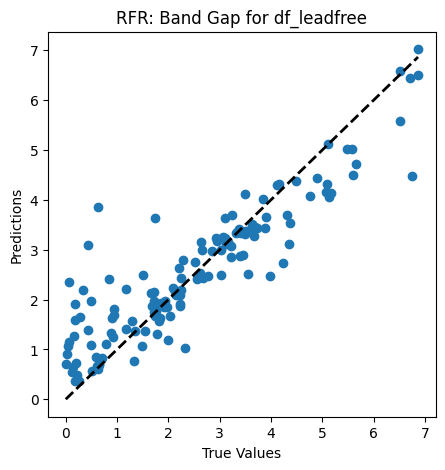

--------------------------------------------
--------------------------------------------
For dataframe: df_abundant
RFR Model| R2 sq on train set: 0.9629
RFR Model| R2 sq on test set: 0.8384
RFR Model| MSE on test set: 0.5150
RFR Model| MAE on test set: 0.5141


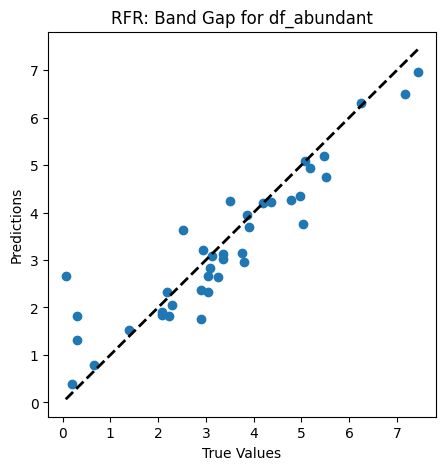

--------------------------------------------


In [64]:
#loop over all dataframes and train model RFR
from sklearn.ensemble import RandomForestRegressor
counter = 0
for df in dfs_with_properties:
  X, y = get_X_y(df)

  X_train8, X_test8, y_train8, y_test8 = train_test_split( X, y, test_size=0.1, random_state=9)
  rfr = GridSearchCV (RandomForestRegressor(),{'max_depth':[20], 'random_state':[0], 'n_estimators': [200], 'criterion':['squared_error']
    }, cv=5)
  rfr.fit(X_train8, y_train8)
  rfr_score = rfr.score(X_train8,y_train8)
  rfr_score1 = rfr.score(X_test8,y_test8)
  y_predicted8 = rfr.predict(X_test8)


  #calculate permutation based feature importance only for df_total
  if df_names[counter] == 'df_total':

    results = permutation_importance(rfr, X_test8, y_test8, n_repeats=5, random_state=42)
    importances = results.importances_mean
    feature_names = X_test8.columns

    importance_df_RFR = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importances
    })
  # Aggregate all SOAP feature importances into one
    soap_start_index = 49 # Index, ab dem die 'soap' Spalten beginnen (0-basiert)
    soap_columns = feature_names[soap_start_index:]

  # Sum of the SOAP importances
    soap_importance = importance_df_RFR[importance_df_RFR['Feature'].isin(soap_columns)]['Importance'].sum()

#print results + scatterplot
  print('--------------------------------------------')
  print('For dataframe:', df_names[counter])
  print('RFR Model| R2 sq on train set: %.4f'% rfr_score)
  print('RFR Model| R2 sq on test set: %.4f'% rfr_score1)
  print('RFR Model| MSE on test set: %.4f'% mean_squared_error(y_test8, y_predicted8))
  print('RFR Model| MAE on test set: %.4f'% mean_absolute_error(y_test8, y_predicted8))

  plt.figure(figsize=(5, 5))
  plt.plot([y_test8.min(), y_test8.max()], [y_test8.min(), y_test8.max()], 'k--', lw=2)
  plt.scatter(y_test8, y_predicted8)
  plt.xlabel("True Values")
  plt.ylabel("Predictions")
  plt.title("RFR: Band Gap for " + df_names[counter])
  plt.savefig(df_names[counter] + "_RFR_band_gap.png", dpi=300)
  plt.show()

  print('--------------------------------------------')
  counter += 1

#ergebnisse jonas ohne soaps(sehr nahe an paper)
#RFR Model| R2 sq on train set: 0.9674
#RFR Model| R2 sq on test set: 0.7687
#RFR Model| MSE on test set: 0.5685
#RFR Model| MAE on test set: 0.5573

In [62]:
#look at performance of the models as a function of train/test split for all dataframes
##takes a while! (16 min for df_total)
##add loop over all dataframes here? -probably not needed
X, y = get_X_y(dfs_with_properties[2])

mean_absolute_error_SVR = []
mean_absolute_error_RFR = []
mean_absolute_error_KNR = []
mean_absolute_error_GBR = []

test_sizes = [0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,0.95]
for test_size_value in test_sizes:
  #SVR
  X_train3, X_test3, y_train3, y_test3 = train_test_split( X, y, test_size=test_size_value, random_state=10)
  steps = [('scaler', StandardScaler()), ('SVM', SVR())]
  pipeline = Pipeline(steps)
  grid = GridSearchCV(pipeline, param_grid= {'SVM__C':[100], 'SVM__gamma':['auto'], 'SVM__kernel': ['rbf'],
                                            'SVM__epsilon':[0.001]}, cv=5)
  grid.fit(X_train3, y_train3)
  svr_score = grid.score(X_train3,y_train3)
  svr_score1 = grid.score(X_test3,y_test3)
  y_predicted3 = grid.predict(X_test3)
  mean_absolute_error_SVR.append(mean_absolute_error(y_test3, y_predicted3))

  #RFR
  X_train8, X_test8, y_train8, y_test8 = train_test_split( X, y, test_size=test_size_value, random_state=9)
  rfr = GridSearchCV (RandomForestRegressor(),{'max_depth':[None], 'random_state':[0], 'criterion':['squared_error']
                                              }, cv=5)
  rfr.fit(X_train8, y_train8)
  rfr_score = rfr.score(X_train8,y_train8)
  rfr_score1 = rfr.score(X_test8,y_test8)
  y_predicted8 = rfr.predict(X_test8)
  mean_absolute_error_RFR.append(mean_absolute_error(y_test8, y_predicted8))

  #KNR
  X_train9, X_test9, y_train9, y_test9 = train_test_split( X, y,test_size=test_size_value, random_state=9)
  knr = GridSearchCV (KNeighborsRegressor(),{'n_neighbors':[4]}, cv=5)
  knr.fit(X_train9, y_train9)
  knr_score = knr.score(X_train9,y_train9)
  knr_score1 = knr.score(X_test9,y_test9)
  y_predicted9 = knr.predict(X_test9)
  mean_absolute_error_KNR.append(mean_absolute_error(y_test9, y_predicted9))

  #GBR
  X_train1, X_test1, y_train1, y_test1 = train_test_split( X, y, test_size=test_size_value, random_state=9)
  gbr = GridSearchCV (GradientBoostingRegressor (),{
      'n_estimators': [2000], 'max_depth': [2], 'min_samples_split': [2], 'learning_rate': [0.1],
      'loss': ['squared_error'], 'random_state':[72]}, cv=5)
  gbr.fit(X_train1, y_train1)
  y_predicted1 = gbr.predict(X_test1)
  gbr_score = gbr.score(X_train1,y_train1)
  gbr_score1 = gbr.score(X_test1,y_test1)
  mean_absolute_error_GBR.append(mean_absolute_error(y_test1, y_predicted1))


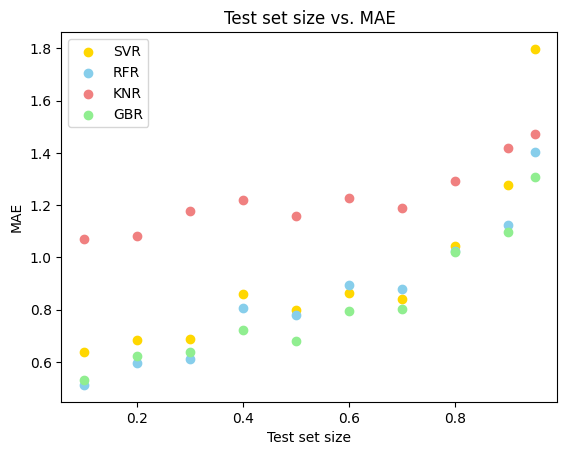

In [63]:
plt.scatter(test_sizes,mean_absolute_error_SVR, label='SVR',color = 'gold')
plt.scatter(test_sizes,mean_absolute_error_RFR, label='RFR',color = 'skyblue')
plt.scatter(test_sizes,mean_absolute_error_KNR, label='KNR',color = 'lightcoral')
plt.scatter(test_sizes,mean_absolute_error_GBR, label='GBR',color = 'lightgreen')
plt.xlabel("Test set size")
plt.ylabel("MAE")
plt.title("Test set size vs. MAE")
plt.legend()

plt.savefig("test_size_importance.png", dpi=300, bbox_inches='tight')

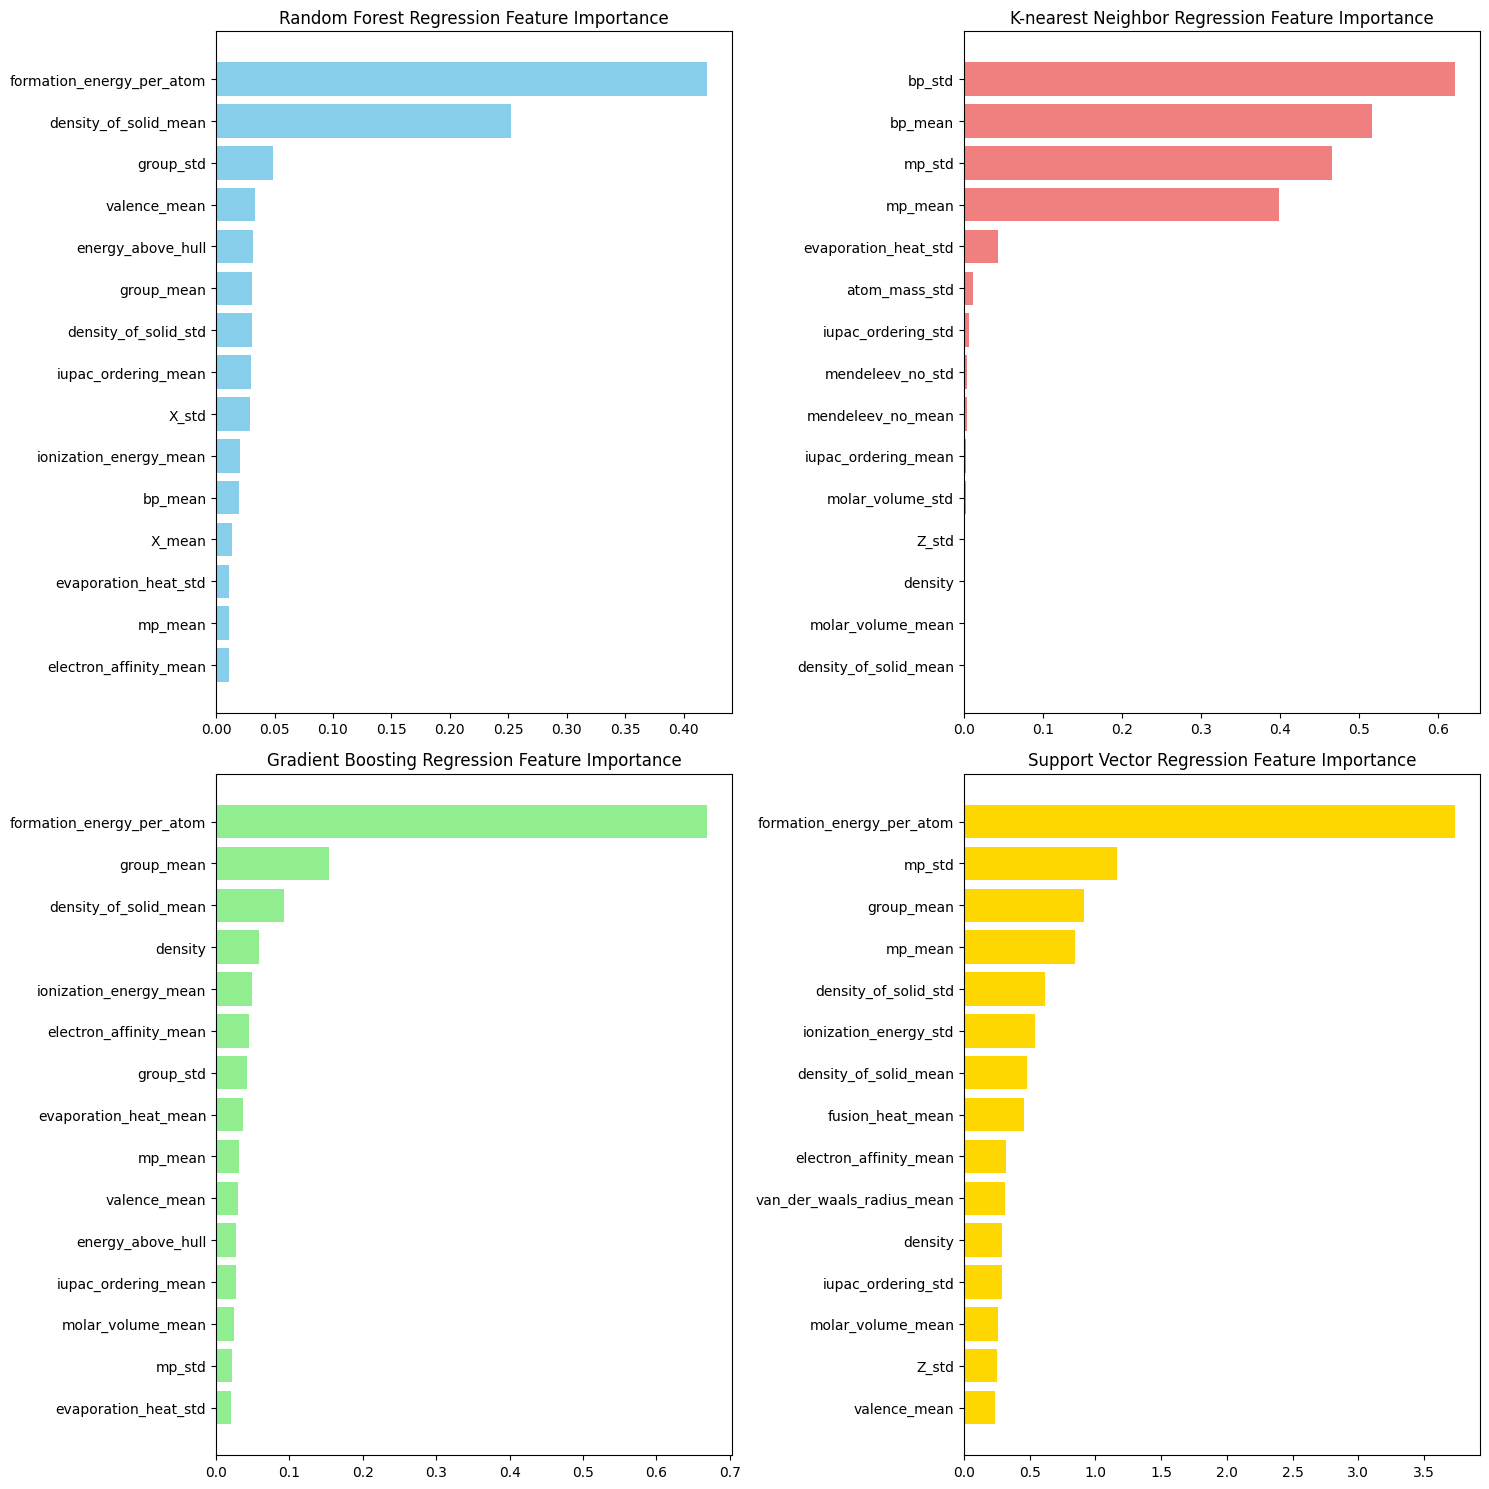

In [71]:
#make barplot of feature importance
# Sort the dataframes by importance
importance_df_RFR = importance_df_RFR.sort_values(by='Importance')
importance_df_KNR = importance_df_KNR.sort_values(by='Importance')
importance_df_GBR = importance_df_GBR.sort_values(by='Importance')
importance_df_SVR = importance_df_SVR.sort_values(by='Importance')

# Create the figure and subplots
fig, axes = plt.subplots(2, 2, figsize=(15, 15))

# Define colors for each model
colors = ['skyblue', 'lightcoral', 'lightgreen', 'gold']

param = 15

# Create horizontal bar plots on the individual Axes objects
axes[0, 0].barh(importance_df_RFR['Feature'].tail(param), importance_df_RFR['Importance'].tail(param), color=colors[0])
axes[0, 0].set_title('Random Forest Regression Feature Importance')

axes[0, 1].barh(importance_df_KNR['Feature'].tail(param), importance_df_KNR['Importance'].tail(param), color=colors[1])
axes[0, 1].set_title('K-nearest Neighbor Regression Feature Importance')

axes[1, 0].barh(importance_df_GBR['Feature'].tail(param), importance_df_GBR['Importance'].tail(param), color=colors[2])
axes[1, 0].set_title('Gradient Boosting Regression Feature Importance')

axes[1, 1].barh(importance_df_SVR['Feature'].tail(param), importance_df_SVR['Importance'].tail(param), color=colors[3])
axes[1, 1].set_title('Support Vector Regression Feature Importance')

# Adjust layout
plt.tight_layout()

plt.savefig("Feature_importance.png", dpi=300)